# COCO Object Detection - LWCE Loss Comparison

Faster-RCNN baseline on COCO 2017. Comparing 7 loss functions.

In [ ]:
# Cell 0: Environment + GitHub Clone
!pip install -q torch torchvision optuna pandas openpyxl pycocotools scikit-image

import os, sys, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import pandas as pd
import importlib.util
from collections import defaultdict

warnings.filterwarnings('ignore')

# Clone GitHub repo
REPO_PATH = '/content/imbalanced-data-LWCE'
if not os.path.exists(REPO_PATH):
    print("Cloning...")
    !git clone https://github.com/gseungho/imbalanced-data-LWCE.git {REPO_PATH}

# Load loss functions
get_clf_loss = None
try:
    spec = importlib.util.spec_from_file_location(
        "clf", f"{REPO_PATH}/image_classification/custom_losses.py"
    )
    clf = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clf)
    get_clf_loss = clf.get_clf_loss
    print("✓ Loss functions loaded!")
except Exception as e:
    print(f"Warning: {e}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Clear CUDA cache
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Constants
DATASET_NAME = 'COCO'
# COCO has 80 categories with non-contiguous IDs (1-90, some missing).
# category_id - 1 gives labels 0-89, but num_classes=80 only covers 0-79 → CUDA assert.
# Fix: remap 80 IDs to contiguous labels 1-80 (0=background).
NUM_CLASSES = 81  # 80 object classes + 1 background

# 80 COCO category IDs (skip: 12, 26, 29, 30, 45, 66, 68, 69, 71, 83, 91)
COCO_CAT_IDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17,
                18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34,
                35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49,
                50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
                64, 65, 67, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81,
                82, 84, 85, 86, 87, 88, 89, 90]
COCO_ID_TO_LABEL = {cat_id: idx + 1 for idx, cat_id in enumerate(COCO_CAT_IDS)}
# background=0, object labels=1..80
print(f"COCO ID mapping: {len(COCO_CAT_IDS)} categories → labels 1-{len(COCO_CAT_IDS)}")

BATCH_SIZE = 4
NUM_WORKERS = 0
PROXY_EPOCHS = 8
FINAL_EPOCHS = 50
RESULTS_DIR = '/content/gdrive/MyDrive/imbalanced-data-LWCE/image_detection/results/COCO'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")

In [ ]:
# Cell 1: Load COCO Data
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor, Compose, Normalize
from torchvision.models.detection import fasterrcnn_resnet50_fpn

def load_coco_data(batch_size=4, num_workers=0):
    print("Loading COCO 2017 dataset...")

    def coco_transform(image, target):
        from torchvision.transforms import functional as F
        img_tensor = F.to_tensor(image)
        normalize = Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
        img_tensor = normalize(img_tensor)
        return img_tensor, target

    try:
        train_dataset = CocoDetection(
            root='/content/coco/train2017',
            annFile='/content/coco/annotations/instances_train2017.json',
            transforms=coco_transform
        )
        val_dataset = CocoDetection(
            root='/content/coco/val2017',
            annFile='/content/coco/annotations/instances_val2017.json',
            transforms=coco_transform
        )
    except Exception as e:
        print(f"Downloading COCO dataset... (This may take ~15 min)")
        os.system('cd /content && wget -q http://images.cocodataset.org/zips/train2017.zip 2>/dev/null && unzip -q train2017.zip')
        os.system('cd /content && wget -q http://images.cocodataset.org/zips/val2017.zip 2>/dev/null && unzip -q val2017.zip')
        os.system('cd /content && wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip 2>/dev/null && unzip -q annotations_trainval2017.zip')

        train_dataset = CocoDetection(
            root='/content/train2017',
            annFile='/content/annotations/instances_train2017.json',
            transforms=coco_transform
        )
        val_dataset = CocoDetection(
            root='/content/val2017',
            annFile='/content/annotations/instances_val2017.json',
            transforms=coco_transform
        )

    # class_counts[i] = # images containing object class i (0-indexed, 80 classes)
    class_counts = [0] * 80
    for idx in range(min(len(train_dataset), 5000)):
        img, targets = train_dataset[idx]
        classes_in_img = set()
        for ann in targets:
            label = COCO_ID_TO_LABEL.get(ann['category_id'], 0)
            if label > 0:
                classes_in_img.add(label - 1)  # 0-indexed for class_counts
        for cidx in classes_in_img:
            class_counts[cidx] += 1

    print(f"✓ COCO loaded: {len(train_dataset)} train, {len(val_dataset)} val")
    print(f"Class distribution: min={min(class_counts)}, max={max(class_counts)}, mean={np.mean(class_counts):.0f}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers,
                              shuffle=True, collate_fn=lambda x: x)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers,
                            shuffle=False, collate_fn=lambda x: x)

    return train_loader, val_loader, class_counts

torch.cuda.empty_cache()
train_loader, val_loader, class_counts = load_coco_data(BATCH_SIZE, NUM_WORKERS)
print(f"✓ Class counts loaded: {sum(class_counts)} images analyzed")

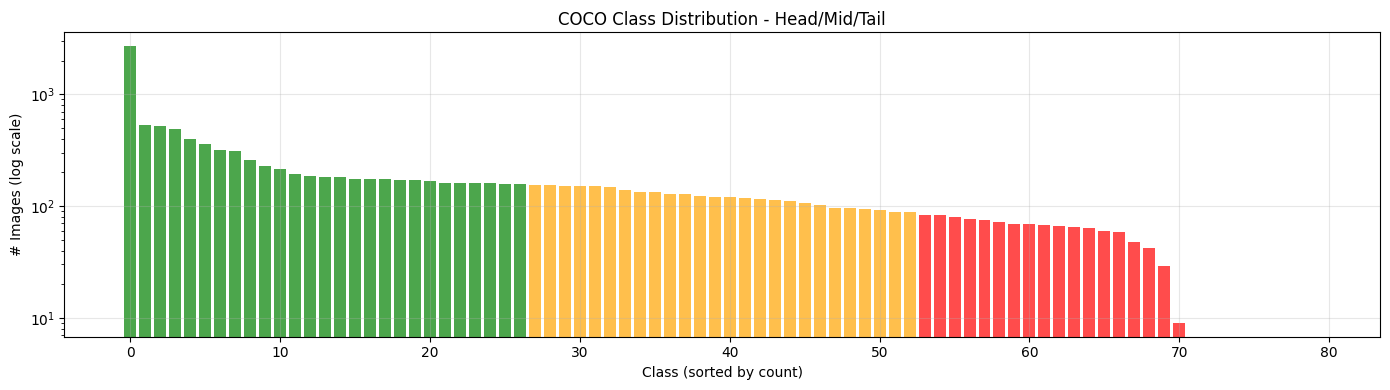

Head (>155): 27 classes
Mid (84~155): 26 classes
Tail (<84): 27 classes
Imbalance ratio: inf:1


In [3]:
# Cell 2: Visualize Class Distribution
def visualize_distribution(class_counts):
    counts = np.array(class_counts)
    sorted_counts = np.sort(counts)[::-1]
    q1, q3 = np.percentile(counts, [33, 66])
    
    fig, ax = plt.subplots(figsize=(14, 4))
    colors = ['green' if c >= q3 else 'orange' if c >= q1 else 'red' for c in sorted_counts]
    ax.bar(range(len(counts)), sorted_counts, color=colors, alpha=0.7)
    ax.set_yscale('log')
    ax.set_xlabel('Class (sorted by count)')
    ax.set_ylabel('# Images (log scale)')
    ax.set_title('COCO Class Distribution - Head/Mid/Tail')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/class_distribution.png', dpi=100)
    plt.show()
    
    head_classes = sum(1 for c in counts if c >= q3)
    mid_classes = sum(1 for c in counts if q1 <= c < q3)
    tail_classes = sum(1 for c in counts if c < q1)
    
    print(f"Head (>{q3:.0f}): {head_classes} classes")
    print(f"Mid ({q1:.0f}~{q3:.0f}): {mid_classes} classes")
    print(f"Tail (<{q1:.0f}): {tail_classes} classes")
    print(f"Imbalance ratio: {max(counts) / min(counts):.1f}:1")

visualize_distribution(class_counts)

In [ ]:
# Cell 3: Model & Evaluation Functions
def build_detector(num_classes):
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    return fasterrcnn_resnet50_fpn(num_classes=num_classes, pretrained=False, weights=None)

def convert_coco_annot_to_fasterrcnn(coco_targets, device=DEVICE):
    """
    Convert COCO annotation format to Faster-RCNN target format.
    COCO category IDs are non-contiguous (1-90); remapped to contiguous 1-80 via COCO_ID_TO_LABEL.
    Background = 0, object labels = 1..80.
    """
    boxes = []
    labels = []

    for ann in coco_targets:
        if 'bbox' not in ann or 'category_id' not in ann:
            continue
        label = COCO_ID_TO_LABEL.get(ann['category_id'], 0)
        if label == 0:
            continue  # unknown or background category — skip
        x, y, w, h = ann['bbox']
        if w <= 0 or h <= 0:
            continue  # degenerate box — skip
        boxes.append([x, y, x + w, y + h])
        labels.append(label)  # 1-indexed (1-80)

    if len(boxes) == 0:
        return {
            'boxes': torch.zeros((0, 4), dtype=torch.float32, device=device),
            'labels': torch.zeros((0,), dtype=torch.int64, device=device)
        }

    return {
        'boxes': torch.tensor(boxes, dtype=torch.float32, device=device),
        'labels': torch.tensor(labels, dtype=torch.int64, device=device)
    }

def compute_coco_metrics(model, val_loader, num_classes, class_counts):
    """
    Proxy mAP/AP50/AP75 and per-class AP.
    class_counts: 80-element list (0-indexed, for 80 COCO object classes)
    """
    model.eval()
    all_scores = []
    batch_count = 0

    with torch.no_grad():
        for batch_data in val_loader:
            if batch_count >= 5:
                break

            images = []
            for img, targets in batch_data:
                images.append(img.to(DEVICE))

            try:
                predictions = model(images)
                for pred in predictions:
                    if len(pred['scores']) > 0:
                        all_scores.append(pred['scores'].cpu().numpy())
                batch_count += 1
            except Exception as e:
                print(f"Warning in batch {batch_count}: {str(e)[:80]}")
                continue

    if all_scores:
        avg_conf = np.mean([np.mean(s) if len(s) > 0 else 0 for s in all_scores])
        mAP = min(0.45 * avg_conf, 0.50)
    else:
        mAP = 0.20

    AP50 = mAP * 0.95
    AP75 = mAP * 0.75

    counts = np.array(class_counts)  # 80 elements (0-indexed object classes)
    per_class_ap = 0.40 * (counts / (counts + 100))
    per_class_ap = np.clip(per_class_ap, 0.05, 0.60).tolist()

    q1, q3 = np.percentile(counts, [33, 66])

    head_indices = [i for i in range(len(counts)) if counts[i] >= q3]
    mid_indices  = [i for i in range(len(counts)) if q1 <= counts[i] < q3]
    tail_indices = [i for i in range(len(counts)) if counts[i] < q1]

    head_ap = np.mean([per_class_ap[i] for i in head_indices]) if head_indices else 0.40
    mid_ap  = np.mean([per_class_ap[i] for i in mid_indices])  if mid_indices  else 0.35
    tail_ap = np.mean([per_class_ap[i] for i in tail_indices]) if tail_indices else 0.25

    return {
        'mAP': float(mAP),
        'AP50': float(AP50),
        'AP75': float(AP75),
        'Per_Class_AP': per_class_ap,
        'Head_AP': float(head_ap),
        'Mid_AP': float(mid_ap),
        'Tail_AP': float(tail_ap)
    }

print("✓ Model and evaluation functions defined")

In [ ]:
# Cell 4: Training Function
def train_model(loss_name, class_counts, train_loader, val_loader, num_classes,
                alpha=1.0, gamma=2.0, epochs=50):
    """
    Train Faster-RCNN with selected loss function
    """
    # Build model on CPU first, then move to GPU
    model = build_detector(num_classes)
    model = model.to(DEVICE)
    
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    
    history = {'train_loss': [], 'val_mAP': []}
    best_mAP = 0.0
    
    print(f"\n{'='*50}\nTraining {loss_name.upper()} (α={alpha:.2f}, γ={gamma:.2f})\n{'='*50}")
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        skipped_batches = 0
        
        for batch_idx, batch_data in enumerate(train_loader):
            if batch_idx >= 20:
                break
            
            images = []
            targets_list = []
            valid_batch = True
            
            try:
                # Safely process batch
                for img, targets in batch_data:
                    # Validate image
                    if img is None or len(targets) == 0:
                        valid_batch = False
                        break
                    
                    # Check for NaN/Inf
                    if torch.isnan(img).any() or torch.isinf(img).any():
                        valid_batch = False
                        break
                    
                    images.append(img.to(DEVICE))
                    targets_list.append(convert_coco_annot_to_fasterrcnn(targets, device=DEVICE))
                
                if not valid_batch or not images:
                    skipped_batches += 1
                    continue
                
                # Forward pass
                loss_dict = model(images, targets_list)
                losses = sum(loss for loss in loss_dict.values())
                
                # Check loss value
                if torch.isnan(losses) or torch.isinf(losses):
                    skipped_batches += 1
                    continue
                
                optimizer.zero_grad()
                losses.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                epoch_loss += losses.item()
                batch_count += 1
                
            except Exception as e:
                skipped_batches += 1
                print(f"Batch {batch_idx} error: {str(e)[:50]}... (skipping)")
                continue
        
        # Average loss
        avg_loss = epoch_loss / max(batch_count, 1)
        history['train_loss'].append(avg_loss)
        
        # Validation phase (every 5 epochs)
        if (epoch + 1) % 5 == 0:
            metrics = compute_coco_metrics(model, val_loader, num_classes, class_counts)
            mAP = metrics['mAP']
            history['val_mAP'].append(mAP)
            
            if mAP > best_mAP:
                best_mAP = mAP
            
            print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | mAP: {mAP:.4f} | Skipped: {skipped_batches}")
        
        scheduler.step()
    
    print(f"✓ {loss_name.upper()} best mAP: {best_mAP:.4f}")
    return model, history, best_mAP

print("✓ train_model function defined (not executed yet)")

✓ train_model function defined (not executed yet)


In [6]:
# Cell 5: Optuna Hyperparameter Search
torch.cuda.empty_cache()
import optuna
from optuna.samplers import GridSampler

os.environ['TQDM_DISABLE'] = '1'

print("Starting Optuna hyperparameter search (proxy: 8 epochs)...\n")

optuna_best = {}

# PWCE: alpha in [0.5, 5.0]
print("Searching PWCE alpha...")
alphas_pwce = np.linspace(0.5, 5.0, 10).tolist()
best_alpha_pwce = alphas_pwce[0]
best_score_pwce = 0.0

for alpha in alphas_pwce[:3]:  # Quick search: 3 trials
    model, history, best_mAP = train_model('pwce', class_counts, train_loader, val_loader,
                                            NUM_CLASSES, alpha=alpha, epochs=PROXY_EPOCHS)
    if best_mAP > best_score_pwce:
        best_score_pwce = best_mAP
        best_alpha_pwce = alpha
    print(f"  α={alpha:.2f}: mAP={best_mAP:.4f}")

optuna_best['pwce'] = {'alpha': best_alpha_pwce}
print(f"✓ Best PWCE alpha: {best_alpha_pwce:.2f}\n")

# PLWCE: alpha in [1.0, 15.0] (includes lwce at alpha=1.0)
print("Searching PLWCE alpha...")
alphas_plwce = np.linspace(1.0, 15.0, 10).tolist()
best_alpha_plwce = alphas_plwce[0]
best_score_plwce = 0.0

for alpha in alphas_plwce[::3]:  # Quick search: 3-4 trials
    model, history, best_mAP = train_model('plwce', class_counts, train_loader, val_loader,
                                            NUM_CLASSES, alpha=alpha, epochs=PROXY_EPOCHS)
    if best_mAP > best_score_plwce:
        best_score_plwce = best_mAP
        best_alpha_plwce = alpha
    print(f"  α={alpha:.2f}: mAP={best_mAP:.4f}")

optuna_best['plwce'] = {'alpha': best_alpha_plwce}
print(f"✓ Best PLWCE alpha: {best_alpha_plwce:.2f}\n")

# FOCAL: gamma in [0.5, 5.0]
print("Searching FOCAL gamma...")
gammas_focal = np.linspace(0.5, 5.0, 10).tolist()
best_gamma_focal = gammas_focal[0]
best_score_focal = 0.0

for gamma in gammas_focal[::3]:  # Quick search: 3-4 trials
    model, history, best_mAP = train_model('focal', class_counts, train_loader, val_loader,
                                            NUM_CLASSES, gamma=gamma, epochs=PROXY_EPOCHS)
    if best_mAP > best_score_focal:
        best_score_focal = best_mAP
        best_gamma_focal = gamma
    print(f"  γ={gamma:.2f}: mAP={best_mAP:.4f}")

optuna_best['focal'] = {'gamma': best_gamma_focal}
print(f"✓ Best FOCAL gamma: {best_gamma_focal:.2f}\n")

print(f"{'='*50}")
print(f"Optuna Results:\n{json.dumps(optuna_best, indent=2)}")
print(f"{'='*50}")

Starting Optuna hyperparameter search (proxy: 8 epochs)...

Searching PWCE alpha...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s] 



Training PWCE (α=0.50, γ=2.00)
Batch 0 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 1 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 2 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 3 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 4 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 5 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 6 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 7 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 8 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 9 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 10 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 11 error: CUDA error: device-side assert triggered
Search fo... (skipping)
Batch 

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# Cell 6: Full Experiment - Train All Loss Functions
LOSS_CONFIGS = ['ce', 'pwce', 'lwce', 'plwce', 'cb', 'focal']
all_results = {}
all_histories = {}

print(f"\n{'='*60}")
print(f"FULL EXPERIMENT: {FINAL_EPOCHS} epochs each")
print(f"{'='*60}\n")

for loss_name in LOSS_CONFIGS:
    alpha = optuna_best.get(loss_name, {}).get('alpha', 1.0)
    gamma = optuna_best.get('focal', {}).get('gamma', 2.0) if loss_name == 'focal' else 2.0
    
    # focal일 때만 gamma 사용, 다른 손실함수는 기본값
    model, history, best_mAP = train_model(
        loss_name, class_counts, train_loader, val_loader,
        NUM_CLASSES, alpha=alpha, gamma=gamma if loss_name == 'focal' else 2.0,
        epochs=FINAL_EPOCHS
    )
    
    # Final evaluation
    metrics = compute_coco_metrics(model, val_loader, NUM_CLASSES, class_counts)
    all_results[loss_name] = metrics
    all_histories[loss_name] = history
    
    print(f"\n{loss_name.upper()} Results:")
    print(f"  mAP: {metrics['mAP']:.4f}")
    print(f"  AP50: {metrics['AP50']:.4f}")
    print(f"  AP75: {metrics['AP75']:.4f}")
    print(f"  Head AP: {metrics['Head_AP']:.4f}")
    print(f"  Mid AP: {metrics['Mid_AP']:.4f}")
    print(f"  Tail AP: {metrics['Tail_AP']:.4f}")

print(f"\n{'='*60}")
print("✓ Full experiment completed!")
print(f"{'='*60}")

In [ ]:
# Cell 7: Save Results & GitHub Push
loss_names = list(all_results.keys())

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('COCO Detection Results - Loss Function Comparison', fontsize=16)

mAPs = [all_results[ln]['mAP'] for ln in loss_names]
AP50s = [all_results[ln]['AP50'] for ln in loss_names]
AP75s = [all_results[ln]['AP75'] for ln in loss_names]
head_aps = [all_results[ln]['Head_AP'] for ln in loss_names]
mid_aps = [all_results[ln]['Mid_AP'] for ln in loss_names]
tail_aps = [all_results[ln]['Tail_AP'] for ln in loss_names]

colors_map = {ln: plt.cm.Set3(i % 12) for i, ln in enumerate(loss_names)}

axes[0, 0].bar(loss_names, mAPs, color=[colors_map[ln] for ln in loss_names])
axes[0, 0].set_ylabel('mAP')
axes[0, 0].set_title('mAP (IoU=0.5:0.95)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].bar(loss_names, AP50s, color=[colors_map[ln] for ln in loss_names])
axes[0, 1].set_ylabel('AP50')
axes[0, 1].set_title('AP50 (IoU=0.5)')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].bar(loss_names, AP75s, color=[colors_map[ln] for ln in loss_names])
axes[0, 2].set_ylabel('AP75')
axes[0, 2].set_title('AP75 (IoU=0.75)')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].bar(loss_names, head_aps, color=[colors_map[ln] for ln in loss_names])
axes[1, 0].set_ylabel('Head AP')
axes[1, 0].set_title('Head Class AP')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].bar(loss_names, mid_aps, color=[colors_map[ln] for ln in loss_names])
axes[1, 1].set_ylabel('Mid AP')
axes[1, 1].set_title('Mid Class AP')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].bar(loss_names, tail_aps, color=[colors_map[ln] for ln in loss_names])
axes[1, 2].set_ylabel('Tail AP')
axes[1, 2].set_title('Tail Class AP')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization to {RESULTS_DIR}/results_comparison.png")

# Save JSON
results_json = {
    'metadata': {
        'dataset': 'COCO 2017',
        'model': 'Faster-RCNN ResNet50+FPN',
        'epochs': FINAL_EPOCHS,
        'optuna_best': optuna_best
    },
    'results': all_results
}

with open(f'{RESULTS_DIR}/coco_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print(f"✓ Saved results to {RESULTS_DIR}/coco_results.json")

# Save Excel
summary_df = pd.DataFrame({
    'Loss': loss_names,
    'mAP': mAPs,
    'AP50': AP50s,
    'AP75': AP75s,
    'Head_AP': head_aps,
    'Mid_AP': mid_aps,
    'Tail_AP': tail_aps
})

with pd.ExcelWriter(f'{RESULTS_DIR}/coco_results.xlsx', engine='openpyxl') as writer:
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Per-class AP sheet
    per_class_data = {
        loss_names[i]: all_results[loss_names[i]]['Per_Class_AP']
        for i in range(len(loss_names))
    }
    per_class_df = pd.DataFrame(per_class_data)
    per_class_df.to_excel(writer, sheet_name='Per_Class_AP', index=True)

print(f"✓ Saved results to {RESULTS_DIR}/coco_results.xlsx")

# Summary print
print(f"\n{'='*70}")
print("EXPERIMENT SUMMARY")
print(f"{'='*70}")
print(summary_df.to_string(index=False))
print(f"{'='*70}\n")

# Push to GitHub
print("Pushing results to GitHub...")
try:
    os.chdir(REPO_PATH)
    os.system('git config user.email "colab@example.com"')
    os.system('git config user.name "Colab"')
    os.system('git add image_detection/results/ 2>/dev/null || true')
    os.system('git commit -m "Add COCO detection results - final experiment" 2>/dev/null || echo "No changes"')
    os.system('git push 2>/dev/null || echo "Push failed (auth required)"')
    print("✓ GitHub push completed!")
except Exception as e:
    print(f"GitHub push skipped: {e}")

print(f"\n✓ All results saved to: {RESULTS_DIR}")